In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import sys, os

sys.path.append(str(Path(os.getcwd()).parent))
from GrooveModel.Utils.DNAValue import *

from scipy.stats import entropy
from scipy.stats import wasserstein_distance


import seaborn as sns
from seaborn import histplot

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use("default")
mpl.rcParams.update(mpl.rcParamsDefault)


# Load Data

In [5]:
eval_data = pd.read_csv('eval_metadata_old.csv')
print(eval_data.shape)
print(eval_data.columns)
eval_data.head()

(37800, 13)
Index(['input_dna', 'input_midi', 'variation', 'model', 'model_type',
       'pretrain_type', 'temperature', 'top_p', 'max_tokens', 'eval_type',
       'unit_count', 'dna', 'midi'],
      dtype='object')


,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


In [6]:
eval_data = eval_data[(eval_data['model_type'] == 'multitask') | (eval_data['model'].str.contains('large'))].reset_index(drop=True)

In [7]:
eval_data

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25196,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25197,EvalData/OriginalInputs/dna/wb_834.json,EvalData/OriginalInputs/midi/wb_834.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,4,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
25198,EvalData/OriginalInputs/dna/wb_834.json,EvalData/OriginalInputs/midi/wb_834.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,4,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...


In [8]:
low_count = eval_data[eval_data['unit_count'] < 10].shape[0]
print(f'Number of entries with unit count < 10: {low_count}')

Number of entries with unit count < 10: 4901


In [9]:
# Filter out entries with very low unit counts
eval_data = eval_data[eval_data['unit_count'] >= 10].reset_index(drop=True)
print(f'Filtered eval data shape: {eval_data.shape}')

Filtered eval data shape: (20299, 13)


In [10]:
sequential_outputs = eval_data[eval_data['model_type'] == 'sequential']
sequential_outputs.head()

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
12600,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12601,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12602,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12603,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
12604,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


In [11]:
multi_outputs = eval_data[eval_data['model_type'] == 'multitask']
multi_outputs.head()

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


# Comparison Metrics

## Sanity checks

In [12]:
def compute_nomml(onsets, tpqn, k=6):
    """
    Compute the Note Onset Median Metric Level (NOMML) heuristic.
    onsets: list of onset ticks (ints)
    tpqn: ticks per quarter note
    k: depth of metric level hierarchy (default=6)
    """
    levels = []

    for o in onsets:
        found = False

        # --- Duple levels (even numbers)
        for j in range(k):
            p = tpqn / (2 ** j)
            if o % p == 0:
                levels.append(2 * j)
                found = True
                break

        # --- Triplet levels (odd numbers)
        if not found:
            for j in range(k):
                p = (2 * tpqn) / (3 * (2 ** j))
                if o % p == 0:
                    levels.append(2 * j + 1)
                    found = True
                    break

        # --- Beyond both grids
        if not found:
            levels.append(2 * k)

    return np.median(levels) if levels else np.nan

In [13]:
# NOMML, DNODR, DNVR, ...
# to sanity check if output is expressive

if Path('giga_eval_results.csv').exists():
    giga_eval_results = pd.read_csv('giga_eval_results.csv')
else:
    results = []

    for dna in eval_data['dna']:
        unique_velocities = set()
        unique_offsets = set()

        with open(dna, 'r') as f:
            data = json.load(f)[0]

            for dna_unit in data.get('DNAUnits', []):
                vel_dict = dna_unit.get('VelocityPerValuePart', {})
                off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

                # Rest case
                if not vel_dict:
                    unique_velocities.add(0)
                    continue
                if not off_dict:
                    unique_offsets.add(0)
                    continue

                # Process velocities
                for v in vel_dict.values():
                    # Convert normalized float back to integer MIDI velocity
                    midi_velocity = int(round(v * 128))
                    # Clamp to valid range [0, 127]
                    midi_velocity = max(0, min(127, midi_velocity))
                    unique_velocities.add(midi_velocity)

                # Process offsets
                for o in off_dict.values():
                    unique_offsets.add(o)

                # nomml
                tpqn = data.get('TicksPerQuarterNote', 480)

                onsets = []
                for dna_unit in data.get('DNAUnits', []):
                    off_dict = dna_unit.get('OffsetTicksPerValuePart', {})
                    for o in off_dict.values():
                        onsets.append(o)

                nomml = compute_nomml(onsets, tpqn)

        results.append({
            'dna_file': dna,
            'unique_velocity_count': len(unique_velocities),
            'dnvr': len(unique_velocities) / 128.0,
            'unique_offset_count': len(unique_offsets),
            'dnodr': len(unique_offsets) / data.get('TicksPerGridUnit', 120),
            'nomml': nomml
        })

    giga_eval_results = pd.DataFrame(results)
    giga_eval_results.to_csv('giga_eval_results.csv', index=False)

In [14]:
giga_eval_results

,dna_file,unique_velocity_count,dnvr,unique_offset_count,dnodr,nomml
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,23,0.179688,4,0.033333,12.0
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,33,0.257812,4,0.033333,12.0
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,33,0.257812,3,0.025000,12.0
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,13,0.101562,3,0.025000,12.0
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,14,0.109375,3,0.025000,12.0
...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,12,0.093750,6,0.050000,12.0
20295,EvalData/sequential_large_finetune_maxtok400/d...,20,0.156250,10,0.083333,12.0
20296,EvalData/sequential_large_finetune_maxtok400/d...,7,0.054688,6,0.050000,12.0
20297,EvalData/sequential_large_finetune_maxtok400/d...,10,0.078125,7,0.058333,12.0


In [15]:
giga_eval_results['nomml'].count()

np.int64(20299)

## Statistical Parameters of Output (mean, std,...)

In [16]:
stats_results = []

if Path('eval_stats.csv').exists():
    stats_results = pd.read_csv('eval_stats.csv').to_dict(orient='records')
else:
    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        def get_stats_from_dna(path):
            with open(path, 'r') as f:
                data = json.load(f)[0]

            all_velocities = []
            all_offsets = []

            for dna_unit in data.get('DNAUnits', []):
                vel_dict = dna_unit.get('VelocityPerValuePart', {})
                off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

                # velocities (normalize → MIDI range)
                for v in vel_dict.values():
                    midi_velocity = int(round(v * 128))
                    midi_velocity = max(0, min(127, midi_velocity))
                    all_velocities.append(midi_velocity)

                # offsets (tick units)
                for o in off_dict.values():
                    all_offsets.append(o)

            # handle empty cases
            if len(all_velocities) == 0:
                all_velocities = [0]
            if len(all_offsets) == 0:
                all_offsets = [0]

            return {
                'vel_mean': np.mean(all_velocities),
                'vel_std': np.std(all_velocities),
                'vel_min': np.min(all_velocities),
                'vel_max': np.max(all_velocities),
                'vel_median': np.median(all_velocities),
                'vel_range': np.ptp(all_velocities),
                'off_mean': np.mean(all_offsets),
                'off_std': np.std(all_offsets),
                'off_min': np.min(all_offsets),
                'off_max': np.max(all_offsets),
                'off_median': np.median(all_offsets),
                'off_range': np.ptp(all_offsets),
            }

        # --- Get stats for both target and input DNA ---
        eval_stats = get_stats_from_dna(dna)
        input_stats = get_stats_from_dna(input_dna)

        # --- Combine into one record ---
        stats_results.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            **{k: v for k, v in eval_stats.items()},
            **{f'input_{k}': v for k, v in input_stats.items()},
        })

    stats_df = pd.DataFrame(stats_results)
    stats_df.to_csv('eval_stats.csv', index=False)

In [17]:
# compare mean std
stats_df = pd.DataFrame(stats_results)
stats_df

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,input_vel_min,input_vel_max,input_vel_median,input_vel_range,input_off_mean,input_off_std,input_off_min,input_off_max,input_off_median,input_off_range
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,99.138462,38.365801,0,127,126.0,127,1.407692,0.664439,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,103.020134,30.548777,33,127,124.0,94,1.281879,0.613938,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,101.098160,39.322360,14,127,124.0,113,1.116564,0.420234,...,26,127,127.0,101,3.382775,7.434363,-33,42,3.0,75
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,119.827225,12.668405,85,127,124.0,42,1.188482,0.453114,...,33,127,127.0,94,2.971831,3.445642,-9,9,3.0,18
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,120.380208,11.482606,85,127,124.0,42,1.156250,0.390729,...,33,127,127.0,94,2.971831,3.445642,-9,9,3.0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,116.282051,21.461891,45,127,127.0,82,-2.307692,3.360051,...,37,127,127.0,90,4.435897,3.447741,-9,12,5.0,21
20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,112.820513,24.139946,45,127,127.0,82,2.423077,6.039441,...,55,127,127.0,72,2.957746,4.845316,-7,30,3.0,37
20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,125.025641,8.078103,77,127,127.0,50,6.846154,3.254492,...,112,127,127.0,15,6.583333,6.812468,-11,26,7.0,37
20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,125.136364,4.515584,98,127,127.0,29,6.784091,3.575322,...,112,127,127.0,15,6.583333,6.812468,-11,26,7.0,37


In [18]:
stats_df.columns

Index(['dna_file', 'input_dna_file', 'vel_mean', 'vel_std', 'vel_min',
       'vel_max', 'vel_median', 'vel_range', 'off_mean', 'off_std', 'off_min',
       'off_max', 'off_median', 'off_range', 'input_vel_mean', 'input_vel_std',
       'input_vel_min', 'input_vel_max', 'input_vel_median', 'input_vel_range',
       'input_off_mean', 'input_off_std', 'input_off_min', 'input_off_max',
       'input_off_median', 'input_off_range'],
      dtype='object')

In [19]:
#
multi_stats = stats_df.merge(
    multi_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)

multi_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,99.138462,38.365801,0,127,126.0,127,1.407692,0.664439,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,103.020134,30.548777,33,127,124.0,94,1.281879,0.613938,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,101.098160,39.322360,14,127,124.0,113,1.116564,0.420234,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,119.827225,12.668405,85,127,124.0,42,1.188482,0.453114,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,120.380208,11.482606,85,127,124.0,42,1.156250,0.390729,...,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...


In [20]:
seq_stats = stats_df.merge(
    sequential_outputs,
    left_on="dna_file",
    right_on="dna",
    how="inner",
    validate="one_to_one"
)
seq_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,111.583333,30.102487,49,127,127.0,78,1.250000,3.614208,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
1,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,105.425532,33.175064,47,127,127.0,80,2.170213,2.529142,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
2,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,107.333333,32.381408,45,127,127.0,82,3.187500,4.171612,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
3,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,114.269231,24.704496,59,127,127.0,68,-0.692308,2.089704,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
4,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,116.962264,22.232020,63,127,127.0,64,-0.396226,2.021951,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


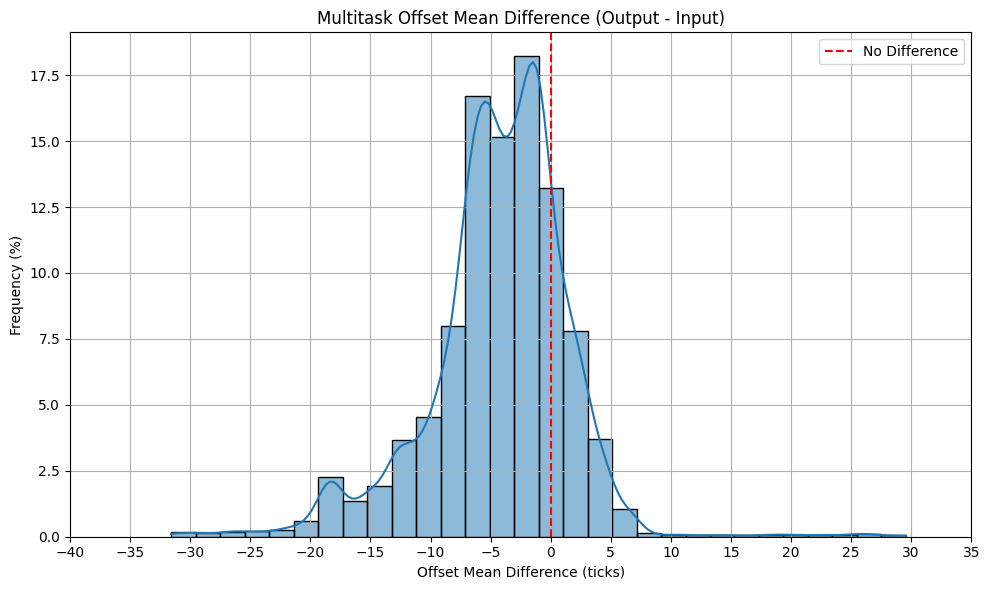

In [21]:
off_diff = multi_stats['off_mean'] - multi_stats['input_off_mean']
off_diff = off_diff[(off_diff >= -40) & (off_diff <= 40)]

plt.figure(figsize=(10, 6))
sns.histplot(off_diff, bins=30, kde=True, stat='percent')
plt.title('Multitask Offset Mean Difference (Output - Input)')
plt.xlabel('Offset Mean Difference (ticks)')
plt.xticks(range(-40, 40, 5))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Difference')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

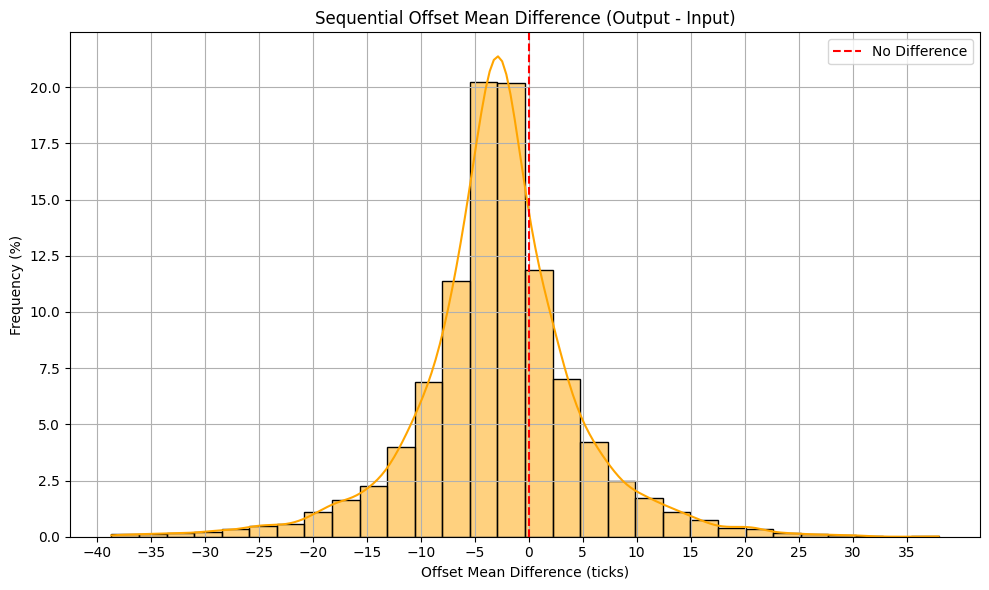

In [22]:
off_diff = seq_stats['off_mean'] - seq_stats['input_off_mean']
off_diff = off_diff[(off_diff >= -40) & (off_diff <= 40)]


plt.figure(figsize=(10, 6))
sns.histplot(off_diff, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Offset Mean Difference (Output - Input)')
plt.xlabel('Offset Mean Difference (ticks)')
plt.xticks(range(-40, 40, 5))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Difference')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

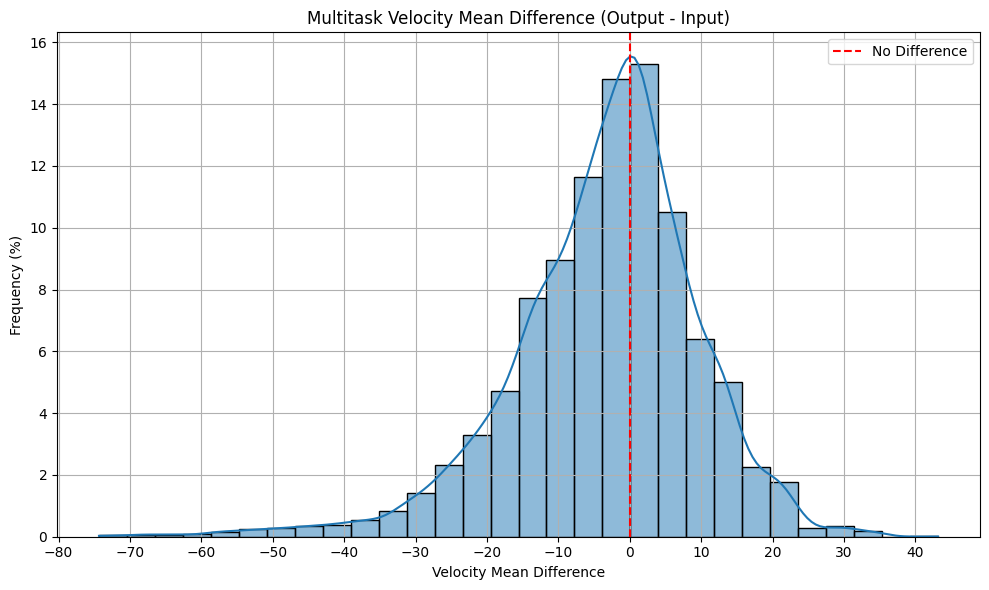

In [23]:
vel_diff = multi_stats['vel_mean'] - multi_stats['input_vel_mean']
vel_diff = vel_diff[vel_diff >= -80]

plt.figure(figsize=(10, 6))
sns.histplot(vel_diff, bins=30, kde=True, stat='percent')
plt.title('Multitask Velocity Mean Difference (Output - Input)')
plt.xlabel('Velocity Mean Difference')
plt.xticks(range(-80, 50, 10))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Difference')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

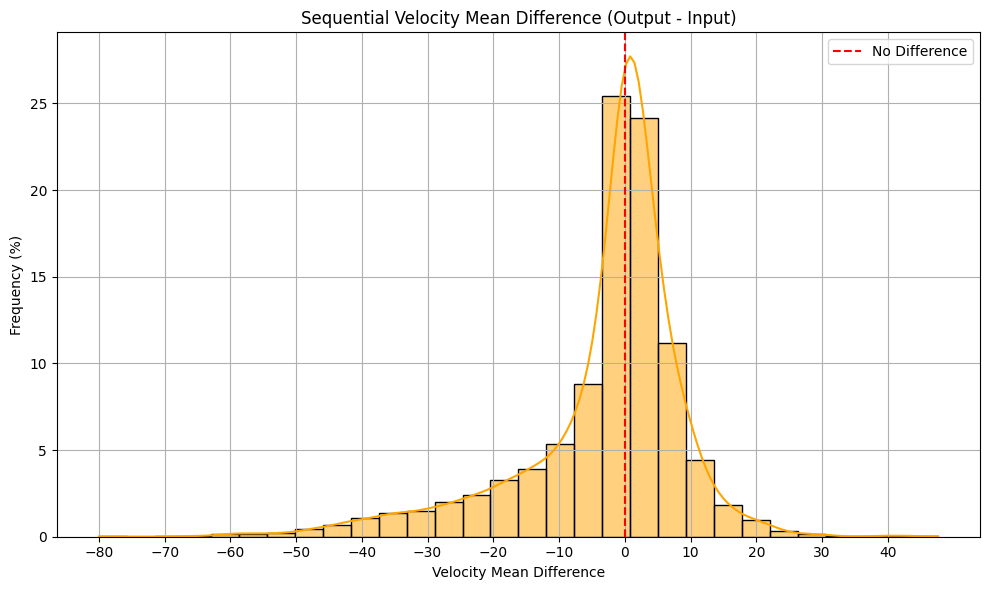

In [24]:
vel_diff = seq_stats['vel_mean'] - seq_stats['input_vel_mean']
vel_diff = vel_diff[vel_diff >= -80]

plt.figure(figsize=(10, 6))
sns.histplot(vel_diff, bins=30, kde=True, stat='percent', color='orange')
plt.title('Sequential Velocity Mean Difference (Output - Input)')
plt.xlabel('Velocity Mean Difference')
plt.xticks(range(-80, 50, 10))
plt.ylabel('Frequency (%)')
plt.axvline(0, color='red', linestyle='--', label='No Difference')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [25]:
# correlations ->
vel_corr = stats_df[['vel_mean', 'input_vel_mean']].corr().iloc[0, 1]
off_corr = stats_df[['off_mean', 'input_off_mean']].corr().iloc[0, 1]
print(f'Velocity Mean Correlation: {vel_corr:.4f}')
print(f'Offset Mean Correlation: {off_corr:.4f}')

Velocity Mean Correlation: 0.2783
Offset Mean Correlation: 0.3080


In [26]:
# table of total mean and std for velocity and offset over sequential and multitask
seq_stats.head()

,dna_file,input_dna_file,vel_mean,vel_std,vel_min,vel_max,vel_median,vel_range,off_mean,off_std,...,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,111.583333,30.102487,49,127,127.0,78,1.250000,3.614208,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,53,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
1,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,105.425532,33.175064,47,127,127.0,80,2.170213,2.529142,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,57,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
2,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_10.json,107.333333,32.381408,45,127,127.0,82,3.187500,4.171612,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,54,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
3,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,114.269231,24.704496,59,127,127.0,68,-0.692308,2.089704,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,43,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...
4,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/OriginalInputs/dna/fbo_10_16.json,116.962264,22.232020,63,127,127.0,64,-0.396226,2.021951,...,sequential_large,sequential,pretrain,0.8,0.8,200,creativeness,39,EvalData/sequential_large_temp0.8_top_p0.8/dna...,EvalData/sequential_large_temp0.8_top_p0.8/mid...


## Kullback Leibler Divergence/ Earth Movers Distance (Wasserstein)/ Mutual Information Score

In [27]:
# compare human vs predicted distributions

dist_results = []

if Path('eval_distances.csv').exists():
    dist_results = pd.read_csv('eval_distances.csv').to_dict(orient='records')
else:
    def get_distributions_from_dna(path):
        with open(path, 'r') as f:
            data = json.load(f)[0]

        all_velocities = []
        all_offsets = []

        for dna_unit in data.get('DNAUnits', []):
            vel_dict = dna_unit.get('VelocityPerValuePart', {})
            off_dict = dna_unit.get('OffsetTicksPerValuePart', {})

            # velocities (normalize → MIDI range)
            for v in vel_dict.values():
                midi_velocity = int(round(v * 128))
                midi_velocity = max(0, min(127, midi_velocity))
                all_velocities.append(midi_velocity)

            # offsets
            for o in off_dict.values():
                all_offsets.append(o)

        # handle empty cases
        if len(all_velocities) == 0:
            all_velocities = [0]
        if len(all_offsets) == 0:
            all_offsets = [0]

        return all_velocities, all_offsets


    def compare_distributions(eval_list, input_list, bins=50):
        """Compute KL (both dirs), JS, Hellinger, Wasserstein distances."""
        a = np.array(eval_list)
        b = np.array(input_list)
        min_val, max_val = min(a.min(), b.min()), max(a.max(), b.max())

        # histograms (density=True gives PDF)
        hist_a, _ = np.histogram(a, bins=bins, range=(min_val, max_val), density=True)
        hist_b, _ = np.histogram(b, bins=bins, range=(min_val, max_val), density=True)

        # avoid zero divisions
        hist_a += 1e-12
        hist_b += 1e-12
        hist_a /= hist_a.sum()
        hist_b /= hist_b.sum()

        # --- metrics ---
        kl_input_output = entropy(hist_b, hist_a)  # KL(input||output)
        kl_output_input = entropy(hist_a, hist_b)  # KL(output||input)

        m = 0.5 * (hist_a + hist_b)
        js_divergence = 0.5 * (entropy(hist_a, m) + entropy(hist_b, m))

        hellinger = np.sqrt(0.5 * np.sum((np.sqrt(hist_a) - np.sqrt(hist_b)) ** 2))

        wass = wasserstein_distance(a, b)

        return {
            'kl_input_output': kl_input_output,
            'kl_output_input': kl_output_input,
            'jensen_shannon': js_divergence,
            'hellinger': hellinger,
            'wasserstein': wass,
        }


    # --- loop through all dna/input pairs ---
    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        vel_eval, off_eval = get_distributions_from_dna(dna)
        vel_in, off_in = get_distributions_from_dna(input_dna)

        vel_stats = compare_distributions(vel_eval, vel_in)
        off_stats = compare_distributions(off_eval, off_in)

        dist_results.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            **{f'vel_{k}': v for k, v in vel_stats.items()},
            **{f'off_{k}': v for k, v in off_stats.items()},
        })

    dist_df = pd.DataFrame(dist_results)
    dist_df.to_csv('eval_distances.csv', index=False)

In [28]:
dist_df = pd.DataFrame(dist_results)
dist_df

,dna_file,input_dna_file,vel_kl_input_output,vel_kl_output_input,vel_jensen_shannon,vel_hellinger,vel_wasserstein,off_kl_input_output,off_kl_output_input,off_jensen_shannon,off_hellinger,off_wasserstein
0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,2.154819,1.834143,0.107399,0.365839,14.048141,13.356923,1.295719,0.321229,0.643612,4.472690
1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,1.752348,4.950548,0.134718,0.423898,10.314312,11.271259,1.492479,0.348039,0.657521,4.598504
2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,1.168660,3.236123,0.154040,0.433580,12.088443,15.522282,1.864881,0.428401,0.736831,4.763818
3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,4.742380,4.195980,0.231637,0.546193,6.344960,14.577903,1.022449,0.289486,0.615280,2.811518
4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,4.759362,4.033864,0.237222,0.552153,6.956353,14.657809,1.067911,0.301886,0.626439,2.843750
...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,3.920786,4.764012,0.130371,0.432922,2.333333,19.912222,18.259473,0.574257,0.894067,6.743590
20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,3.340730,4.998869,0.128865,0.428984,3.711809,20.051408,7.481827,0.459136,0.790909,1.332430
20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,1.384203,2.447939,0.055103,0.281712,1.250000,18.615059,10.111869,0.432914,0.777449,2.694444
20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,0.141655,2.431828,0.045377,0.247290,1.133838,18.714695,14.219921,0.471523,0.817239,2.531566


## Dynamic Range Comparison

In [29]:
# compare velocity ranges

dynamic_ranges = stats_df[['vel_range', 'input_vel_range', 'off_range', 'input_off_range']]
dynamic_ranges["vel_range_diff"] = abs(dynamic_ranges['vel_range'] - dynamic_ranges['input_vel_range'])
dynamic_ranges["off_range_diff"] = abs(dynamic_ranges['off_range'] - dynamic_ranges['input_off_range'])
dynamic_ranges

C:\Users\minem\AppData\Local\Temp\ipykernel_10148\118704695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_ranges["vel_range_diff"] = abs(dynamic_ranges['vel_range'] - dynamic_ranges['input_vel_range'])
C:\Users\minem\AppData\Local\Temp\ipykernel_10148\118704695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dynamic_ranges["off_range_diff"] = abs(dynamic_ranges['off_range'] - dynamic_ranges['input_off_range'])


,vel_range,input_vel_range,off_range,input_off_range,vel_range_diff,off_range_diff
0,127,101,3,75,26,72
1,94,101,4,75,7,71
2,113,101,4,75,12,71
3,42,94,2,18,52,16
4,42,94,2,18,52,16
...,...,...,...,...,...,...
20294,82,90,15,21,8,6
20295,82,72,54,37,10,17
20296,50,15,15,37,35,22
20297,29,15,21,37,14,16


## Drum Pattern Comparison

In [30]:
def bit_indexes(n):
    return [i for i in range(n.bit_length()) if (n >> i) & 1]

In [31]:
example = eval_data.iloc[0]
example

input_dna               EvalData/OriginalInputs/dna/fbo_10_10.json
input_midi              EvalData/OriginalInputs/midi/fbo_10_10.mid
variation                                                        0
model                                     multitask_relgu_finetune
model_type                                               multitask
pretrain_type                                             finetune
temperature                                                    0.8
top_p                                                          0.8
max_tokens                                                     200
eval_type                                             creativeness
unit_count                                                     144
dna              EvalData/multitask_relgu_finetune_temp0.8_top_...
midi             EvalData/multitask_relgu_finetune_temp0.8_top_...
Name: 0, dtype: object

In [32]:
# plot drum patterns of input and some variations
with open(example['input_dna'], 'r') as f:
    input_data = json.load(f)[0]
with open(example['dna'], 'r') as f:
    output_data = json.load(f)[0]

input_units = input_data.get('DNAUnits', [])
output_units = output_data.get('DNAUnits', [])

len_input = len(input_units)
len_output = len(output_units)

gf = input_data.get('GridFactor', 4)
tpgu = input_data.get('TicksPerGridUnit', 120)
tpqn = input_data.get('TicksPerQuarterNote', 480)

input_pattern = np.zeros((len_input, len(InstrumentValues)))
output_pattern = np.zeros((len_output, len(InstrumentValues)))

for i, unit in enumerate(input_units):
    inst = unit.get('Value', 0)
    vel_dict = unit.get('VelocityPerValuePart', {})
    off_dict = unit.get('OffsetTicksPerValuePart', {})

    inst_parts = bit_indexes(inst)

    for part in inst_parts:
        input_pattern[i, part] = 1


for i, unit in enumerate(output_units):
    inst = unit.get('Value', 0)
    vel_dict = unit.get('VelocityPerValuePart', {})
    off_dict = unit.get('OffsetTicksPerValuePart', {})

    inst_parts = bit_indexes(inst)

    for part in inst_parts:
        output_pattern[i, part] = 1

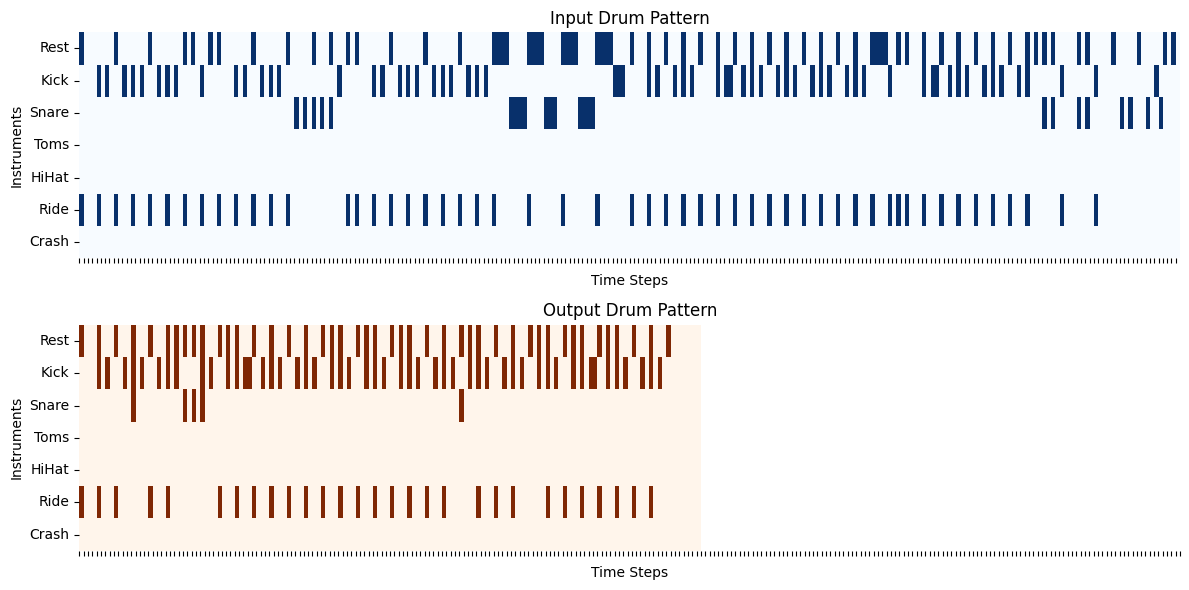

In [33]:
instrument_keys = [name for name, val in InstrumentValues.__members__.items()]

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
sns.heatmap(input_pattern.T, cmap='Blues', cbar=False)
plt.yticks(np.arange(len(instrument_keys)) + 0.5, instrument_keys, rotation=0)
plt.xticks(np.arange(len_input), rotation=0)
plt.title('Input Drum Pattern')
plt.xlabel('Time Steps')
plt.ylabel('Instruments')
plt.subplot(2, 1, 2)
sns.heatmap(output_pattern.T, cmap='Oranges', cbar=False)
plt.yticks(np.arange(len(instrument_keys)) + 0.5, instrument_keys, rotation=0)
plt.xticks(np.arange(len_input), rotation=0)
plt.title('Output Drum Pattern')
plt.xlabel('Time Steps')
plt.ylabel('Instruments')
plt.tight_layout()
plt.show()

## Heatmaps, Distribution Plots

In [34]:
# maybe like in bac, plot instrument to next instrument transitions
# or overall instrument / microtiming / velocity densities or heatmaps

microtimings = list()
velocities = list()
instruments = list()

for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
    with open(dna, 'r') as f:
        data = json.load(f)[0]
        for dna_unit in data.get('DNAUnits', []):
            off_dict = dna_unit.get('OffsetTicksPerValuePart', {})
            vel_dict = dna_unit.get('VelocityPerValuePart', {})
            inst = dna_unit.get('Value', 0)
            inst_parts = bit_indexes(inst)
            instruments.extend(inst_parts)
            for o in off_dict.values():
                microtimings.append(o)
            for v in vel_dict.values():
                midi_velocity = int(round(v * 128))
                midi_velocity = max(0, min(127, midi_velocity))
                velocities.append(midi_velocity)

In [35]:
instruments = [i for i in instruments if i < len(RemappedInstrumentValues)]
max(instruments)

6

In [36]:
instrument_mapping = RemappedInstrumentValues.__members__.items()
instrument_lookup = {val.value - 1: name for name, val in instrument_mapping}
instrument_names = [instrument_lookup[i] for i in instruments]

In [37]:
print("Number of instruments:", len(instruments))
print("Unique instruments:", len(set(instruments)))
print("Counts:", {i: instruments.count(i) for i in set(instruments)})

Number of instruments: 2086620
Unique instruments: 7
Counts: {0: 556297, 1: 629479, 2: 458528, 3: 248378, 4: 117106, 5: 76674, 6: 158}


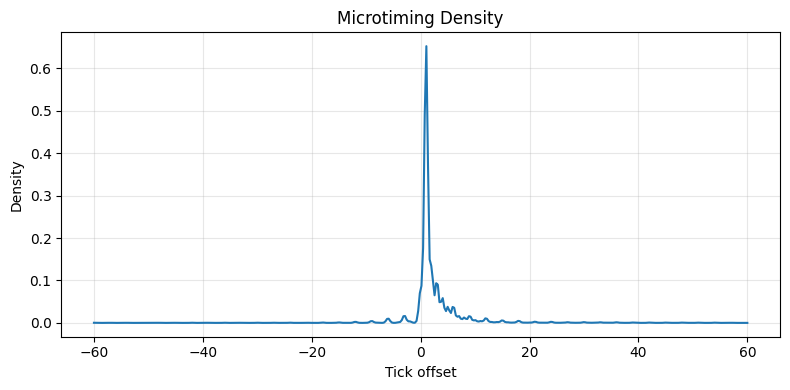

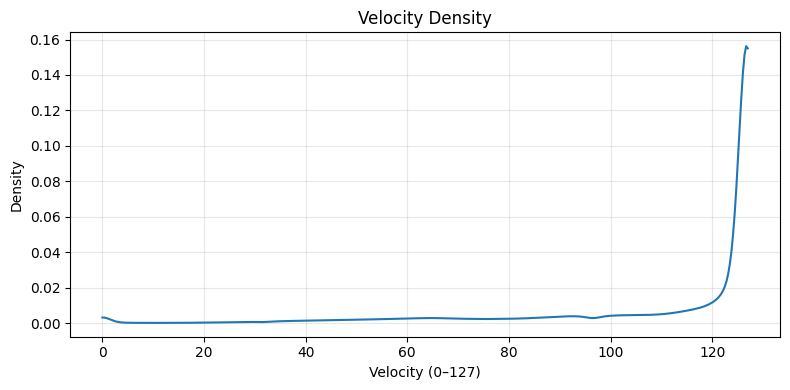

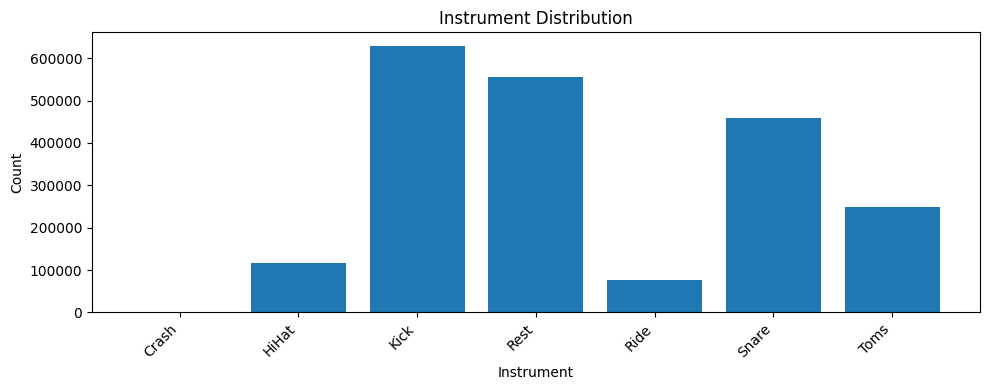

In [38]:
# ---- DENSITY PLOT FUNCTION ----
def density_plot(data, title, xlabel):
    data = np.array(data)
    plt.figure(figsize=(8, 4))

    # density estimate (manual KDE)
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)

    xmin, xmax = data.min(), data.max()
    xs = np.linspace(xmin, xmax, 400)
    ys = kde(xs)

    plt.plot(xs, ys)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ---- PLOT MICROTIMINGS ----
density_plot(microtimings, "Microtiming Density", "Tick offset")

# ---- PLOT VELOCITIES ----
density_plot(velocities, "Velocity Density", "Velocity (0–127)")

# ---- INSTRUMENT FREQUENCY PLOT ----
plt.figure(figsize=(10, 4))
unique, counts = np.unique(instrument_names, return_counts=True)
plt.bar(unique, counts)
plt.title("Instrument Distribution")
plt.xlabel("Instrument")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Consistent Rhythm Pattern

In [39]:
# are the pulses consistent?

if Path('eval_pulse_deviations.csv').exists():
    pulse_dev_df = pd.read_csv('eval_pulse_deviations.csv')
else:
    pulse_deviations = []

    for dna, input_dna in zip(eval_data['dna'], eval_data['input_dna']):
        with open(dna, 'r') as f:
            data = json.load(f)[0]
        with open(input_dna, 'r') as f:
            input_data = json.load(f)[0]

        input_pulses = []
        for dna_unit in input_data.get('DNAUnits', []):
            if not dna_unit.get('IsEmpty', True):
                input_pulses.append(1)
            else:
                input_pulses.append(0)

        output_pulses = []
        for dna_unit in data.get('DNAUnits', []):
            if not dna_unit.get('IsEmpty', True):
                output_pulses.append(1)
            else:
                output_pulses.append(0)

        if len(input_pulses) > len(output_pulses):
            input_pulses = input_pulses[:len(output_pulses)]
        elif len(output_pulses) > len(input_pulses):
            output_pulses = output_pulses[:len(input_pulses)]

        hamming_distance = sum(i != o for i, o in zip(input_pulses, output_pulses))
        corr = np.correlate(output_pulses, input_pulses, mode='full')
        shift = np.argmax(corr) - (len(input_pulses) - 1)
        per_pos = [abs(i-o) for i,o in zip(input_pulses, output_pulses)]
        deviation_count = sum(per_pos)

        pulse_deviations.append({
            'dna_file': dna,
            'input_dna_file': input_dna,
            'sequence_length': len(input_pulses),
            'hamming_distance': hamming_distance,
            'shift': shift,
            'deviation_count': deviation_count,
            'per_position': per_pos,
        })

    pulse_dev_df = pd.DataFrame(pulse_deviations)
    pulse_dev_df.to_csv('eval_pulse_deviations.csv')


In [40]:
pulse_dev_df

,Unnamed: 0,dna_file,input_dna_file,sequence_length,hamming_distance,shift,deviation_count,per_position
0,0,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,144,20,-6,20,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,144,31,0,31,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, ..."
2,2,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_10.json,160,46,0,46,"[0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, ..."
3,3,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,128,46,-16,46,"[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ..."
4,4,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/OriginalInputs/dna/fbo_10_16.json,128,45,-16,45,"[0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...
20294,20294,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6939.json,33,3,0,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
20295,20295,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_6967.json,64,4,0,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
20296,20296,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,32,5,1,5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
20297,20297,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/OriginalInputs/dna/wb_724.json,32,5,1,5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


## Comparing Parameter settings (temp, top-p, max_tokens)

In [41]:
# Memory usage, processing power required,...
eval_data

,input_dna,input_midi,variation,model,model_type,pretrain_type,temperature,top_p,max_tokens,eval_type,unit_count,dna,midi
0,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
1,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,144,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
2,EvalData/OriginalInputs/dna/fbo_10_10.json,EvalData/OriginalInputs/midi/fbo_10_10.mid,2,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,160,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
3,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,0,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
4,EvalData/OriginalInputs/dna/fbo_10_16.json,EvalData/OriginalInputs/midi/fbo_10_16.mid,1,multitask_relgu_finetune,multitask,finetune,0.8,0.8,200,creativeness,128,EvalData/multitask_relgu_finetune_temp0.8_top_...,EvalData/multitask_relgu_finetune_temp0.8_top_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20294,EvalData/OriginalInputs/dna/wb_6939.json,EvalData/OriginalInputs/midi/wb_6939.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,33,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20295,EvalData/OriginalInputs/dna/wb_6967.json,EvalData/OriginalInputs/midi/wb_6967.mid,2,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,65,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20296,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,0,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,35,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...
20297,EvalData/OriginalInputs/dna/wb_724.json,EvalData/OriginalInputs/midi/wb_724.mid,1,sequential_large_finetune,sequential,finetune,1.0,0.9,400,sequence_length,67,EvalData/sequential_large_finetune_maxtok400/d...,EvalData/sequential_large_finetune_maxtok400/m...


In [42]:
param_groups = eval_data.groupby(['temperature', 'top_p', 'max_tokens']).size().reset_index(name='count')
param_groups

,temperature,top_p,max_tokens,count
0,0.8,0.80,200,2037
1,0.8,0.90,200,2032
2,0.8,0.95,200,2011
3,1.0,0.80,200,2009
4,1.0,0.90,100,968
5,1.0,0.90,200,2914
6,1.0,0.90,400,958
7,1.0,0.95,200,1934
8,1.2,0.80,200,1909
9,1.2,0.90,200,1777
